**Tonny Talukder
0432220005101050**

In [31]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
import numpy as np
import time
import random

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [32]:
# Normalize grayscale images

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [33]:
train_dataset = datasets.EMNIST(
    root="./data",
    split="letters",
    train=True,
    transform=transform,
    download=True
)

test_dataset = datasets.EMNIST(
    root="./data",
    split="letters",
    train=False,
    transform=transform,
    download=True
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

print("Train Dataset Size:", len(train_dataset))
print("Test Dataset Size:", len(test_dataset))

Train Dataset Size: 124800
Test Dataset Size: 20800


In [34]:
sample_image, sample_label = train_dataset[0]

print("Image Tensor Shape:", sample_image.shape)
print("Label:", sample_label)

Image Tensor Shape: torch.Size([1, 28, 28])
Label: 23


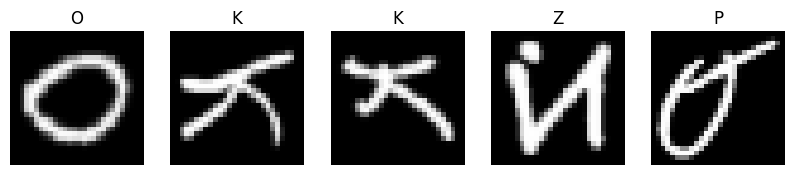

In [35]:
letters = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"

plt.figure(figsize=(10,4))

for i in range(5):

    idx = random.randint(0, len(train_dataset))

    img, label = train_dataset[idx]

    letter = letters[label-1]

    plt.subplot(1,5,i+1)
    plt.imshow(img.squeeze(), cmap="gray")
    plt.title(letter)
    plt.axis("off")

plt.show()

In [36]:
def train_model(model, optimizer, train_loader, val_loader, epochs=10):

    train_losses = []
    val_losses = []

    start_time = time.time()

    for epoch in range(epochs):

        model.train()
        running_loss = 0

        for X, y in train_loader:

            X, y = X.to(device), y.to(device)

            y = y - 1

            X = X.view(X.size(0), -1)

            optimizer.zero_grad()

            output = model(X)

            loss = F.cross_entropy(output, y)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

        train_loss = running_loss / len(train_loader)
        train_losses.append(train_loss)


        model.eval()
        val_loss = 0
        correct = 0

        with torch.no_grad():

            for X, y in val_loader:

                X, y = X.to(device), y.to(device)

                y = y - 1

                X = X.view(X.size(0), -1)

                output = model(X)

                loss = F.cross_entropy(output, y)

                val_loss += loss.item()

                preds = output.argmax(dim=1)

                correct += (preds == y).sum().item()

        val_loss = val_loss / len(val_loader)
        acc = 100 * correct / len(val_loader.dataset)

        val_losses.append(val_loss)

        print(f"Epoch {epoch+1} | Train Loss {train_loss:.4f} | Val Loss {val_loss:.4f} | Acc {acc:.2f}%")

    end_time = time.time()

    training_time = end_time - start_time

    return train_losses, val_losses, acc, training_time

In [37]:
def plot_losses(train_losses, val_losses, title):

    plt.figure(figsize=(6,4))

    plt.plot(train_losses,label="Train Loss")
    plt.plot(val_losses,label="Validation Loss")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)

    plt.legend()
    plt.show()

In [38]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [39]:
class MLP(nn.Module):

    def __init__(self, layers):
        super().__init__()

        self.layers = nn.ModuleList(
            [nn.Linear(layers[i], layers[i+1]) for i in range(len(layers)-1)]
        )

    def forward(self,x):

        for layer in self.layers[:-1]:
            x = F.relu(layer(x))

        return self.layers[-1](x)

Epoch 1 | Train Loss 1.2614 | Val Loss 1.0488 | Acc 69.46%
Epoch 2 | Train Loss 0.9673 | Val Loss 0.9174 | Acc 73.20%
Epoch 3 | Train Loss 0.8697 | Val Loss 0.8393 | Acc 75.30%
Epoch 4 | Train Loss 0.8079 | Val Loss 0.8018 | Acc 76.00%
Epoch 5 | Train Loss 0.7627 | Val Loss 0.7588 | Acc 77.74%
Epoch 6 | Train Loss 0.7275 | Val Loss 0.7321 | Acc 78.34%
Epoch 7 | Train Loss 0.7047 | Val Loss 0.7107 | Acc 78.88%
Epoch 8 | Train Loss 0.6867 | Val Loss 0.6989 | Acc 79.37%
Epoch 9 | Train Loss 0.6737 | Val Loss 0.6960 | Acc 79.69%
Epoch 10 | Train Loss 0.6654 | Val Loss 0.6917 | Acc 79.43%


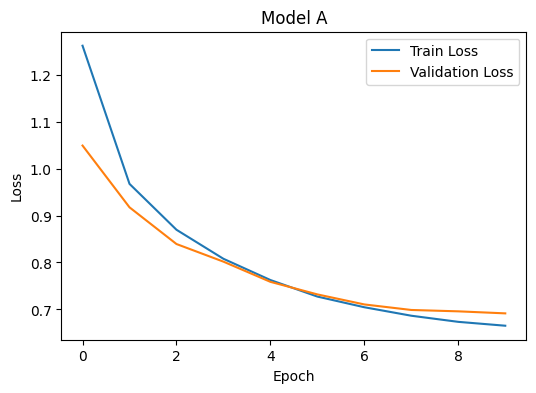

In [40]:
model_A = MLP([784,32,26]).to(device)

opt = optim.Adam(model_A.parameters(), lr=1e-3)

trA, vaA, accA, timeA = train_model(model_A, opt, train_loader, test_loader, epochs=10)

paramsA = count_parameters(model_A)

plot_losses(trA,vaA,"Model A")

Epoch 1 | Train Loss 0.9255 | Val Loss 0.5822 | Acc 82.25%
Epoch 2 | Train Loss 0.5157 | Val Loss 0.4805 | Acc 85.16%
Epoch 3 | Train Loss 0.4303 | Val Loss 0.4266 | Acc 86.85%
Epoch 4 | Train Loss 0.3886 | Val Loss 0.4101 | Acc 87.16%
Epoch 5 | Train Loss 0.3620 | Val Loss 0.3814 | Acc 88.16%
Epoch 6 | Train Loss 0.3402 | Val Loss 0.3921 | Acc 87.94%
Epoch 7 | Train Loss 0.3270 | Val Loss 0.3910 | Acc 87.75%
Epoch 8 | Train Loss 0.3136 | Val Loss 0.3775 | Acc 88.59%
Epoch 9 | Train Loss 0.3037 | Val Loss 0.3690 | Acc 88.60%
Epoch 10 | Train Loss 0.2945 | Val Loss 0.3724 | Acc 88.61%


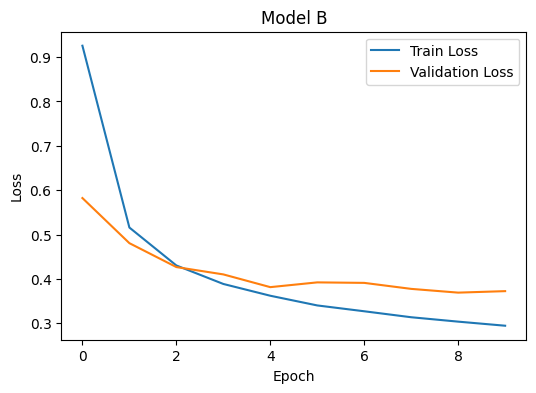

In [41]:
model_B = MLP([784,128,64,26]).to(device)

opt = optim.Adam(model_B.parameters(), lr=1e-3)

trB, vaB, accB, timeB = train_model(model_B, opt, train_loader, test_loader, epochs=10)

paramsB = count_parameters(model_B)

plot_losses(trB,vaB,"Model B")

Epoch 1 | Train Loss 0.8269 | Val Loss 0.5247 | Acc 83.07%
Epoch 2 | Train Loss 0.4296 | Val Loss 0.4126 | Acc 87.02%
Epoch 3 | Train Loss 0.3509 | Val Loss 0.3908 | Acc 87.49%
Epoch 4 | Train Loss 0.3143 | Val Loss 0.3512 | Acc 88.82%
Epoch 5 | Train Loss 0.2870 | Val Loss 0.3495 | Acc 89.00%
Epoch 6 | Train Loss 0.2680 | Val Loss 0.3201 | Acc 89.92%
Epoch 7 | Train Loss 0.2511 | Val Loss 0.3307 | Acc 89.82%
Epoch 8 | Train Loss 0.2385 | Val Loss 0.3257 | Acc 89.79%
Epoch 9 | Train Loss 0.2262 | Val Loss 0.3216 | Acc 90.22%
Epoch 10 | Train Loss 0.2157 | Val Loss 0.3193 | Acc 90.36%


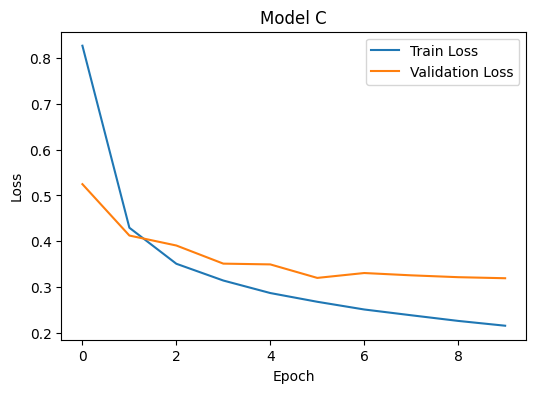

In [42]:
model_C = MLP([784,256,128,64,26]).to(device)

opt = optim.Adam(model_C.parameters(), lr=1e-3)

trC, vaC, accC, timeC = train_model(model_C, opt, train_loader, test_loader, epochs=10)

paramsC = count_parameters(model_C)

plot_losses(trC,vaC,"Model C")

Epoch 1 | Train Loss 2.7689 | Val Loss 2.5656 | Acc 19.43%
Epoch 2 | Train Loss 2.5047 | Val Loss 2.4705 | Acc 22.03%
Epoch 3 | Train Loss 2.4355 | Val Loss 2.4152 | Acc 23.24%
Epoch 4 | Train Loss 2.4029 | Val Loss 2.3950 | Acc 22.99%
Epoch 5 | Train Loss 2.3848 | Val Loss 2.3818 | Acc 23.53%
Epoch 6 | Train Loss 2.3739 | Val Loss 2.3714 | Acc 23.42%
Epoch 7 | Train Loss 2.3670 | Val Loss 2.3640 | Acc 23.94%
Epoch 8 | Train Loss 2.3596 | Val Loss 2.3652 | Acc 23.69%
Epoch 9 | Train Loss 2.3562 | Val Loss 2.3530 | Acc 24.62%
Epoch 10 | Train Loss 2.3530 | Val Loss 2.3766 | Acc 24.21%


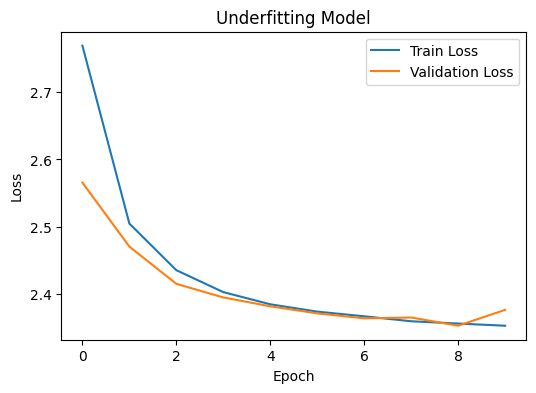

In [43]:
small_model = MLP([784,4,26]).to(device)

opt = optim.Adam(small_model.parameters(),lr=1e-3)

trS,vaS,accS,timeS = train_model(small_model,opt,train_loader,test_loader,epochs=10)

plot_losses(trS,vaS,"Underfitting Model")

Epoch 1 | Train Loss 0.9162 | Val Loss 0.5131 | Acc 84.18%
Epoch 2 | Train Loss 0.4281 | Val Loss 0.3958 | Acc 87.66%
Epoch 3 | Train Loss 0.3452 | Val Loss 0.3478 | Acc 89.36%
Epoch 4 | Train Loss 0.3010 | Val Loss 0.3610 | Acc 89.22%
Epoch 5 | Train Loss 0.2713 | Val Loss 0.3339 | Acc 90.34%
Epoch 6 | Train Loss 0.2491 | Val Loss 0.3225 | Acc 90.28%
Epoch 7 | Train Loss 0.2309 | Val Loss 0.3126 | Acc 90.46%
Epoch 8 | Train Loss 0.2160 | Val Loss 0.3041 | Acc 90.83%
Epoch 9 | Train Loss 0.2057 | Val Loss 0.3000 | Acc 91.31%
Epoch 10 | Train Loss 0.1956 | Val Loss 0.3176 | Acc 90.82%


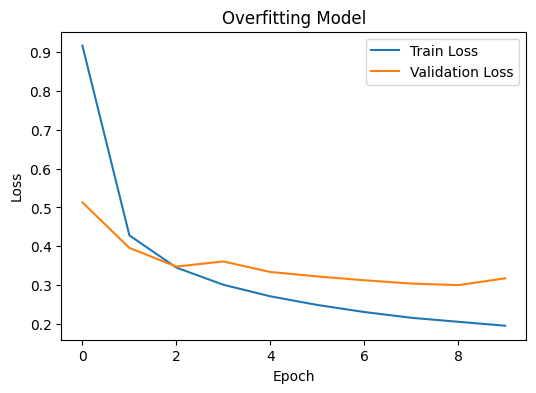

In [44]:
large_model = MLP([784,1024,512,512,256,128,64,26]).to(device)

opt = optim.Adam(large_model.parameters(),lr=1e-3)

trL,vaL,accL,timeL = train_model(large_model,opt,train_loader,test_loader,epochs=10)

plot_losses(trL,vaL,"Overfitting Model")

In [45]:
class MLPBatchNorm(nn.Module):

    def __init__(self):

        super().__init__()

        self.fc1 = nn.Linear(784,256)
        self.bn1 = nn.BatchNorm1d(256)

        self.fc2 = nn.Linear(256,128)
        self.bn2 = nn.BatchNorm1d(128)

        self.fc3 = nn.Linear(128,64)
        self.bn3 = nn.BatchNorm1d(64)

        self.fc4 = nn.Linear(64,26)


    def forward(self,x):

        x = F.relu(self.bn1(self.fc1(x)))
        x = F.relu(self.bn2(self.fc2(x)))
        x = F.relu(self.bn3(self.fc3(x)))

        return self.fc4(x)

Epoch 1 | Train Loss 0.6168 | Val Loss 0.3476 | Acc 88.76%
Epoch 2 | Train Loss 0.3363 | Val Loss 0.3037 | Acc 90.14%
Epoch 3 | Train Loss 0.2833 | Val Loss 0.2807 | Acc 90.85%
Epoch 4 | Train Loss 0.2534 | Val Loss 0.2661 | Acc 91.39%
Epoch 5 | Train Loss 0.2329 | Val Loss 0.2592 | Acc 91.51%
Epoch 6 | Train Loss 0.2121 | Val Loss 0.2630 | Acc 91.62%
Epoch 7 | Train Loss 0.1982 | Val Loss 0.2631 | Acc 91.50%
Epoch 8 | Train Loss 0.1870 | Val Loss 0.2554 | Acc 92.05%
Epoch 9 | Train Loss 0.1765 | Val Loss 0.2581 | Acc 91.72%
Epoch 10 | Train Loss 0.1676 | Val Loss 0.2564 | Acc 91.83%


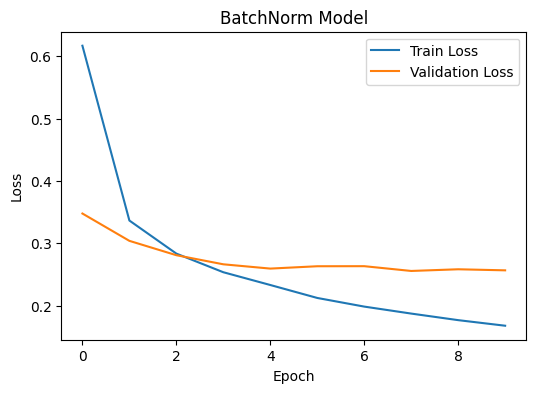

In [46]:
model_bn = MLPBatchNorm().to(device)

opt = optim.Adam(model_bn.parameters(),lr=1e-3)

trBN,vaBN,accBN,timeBN = train_model(model_bn,opt,train_loader,test_loader,epochs=10)

paramsBN = count_parameters(model_bn)

plot_losses(trBN,vaBN,"BatchNorm Model")

In [47]:
def compute_confusion_matrix(model,loader,num_classes=26):

    cm = np.zeros((num_classes,num_classes),dtype=int)

    model.eval()

    with torch.no_grad():

        for X,y in loader:

            y = y - 1

            X = X.to(device)

            out = model(X.view(X.size(0),-1))

            preds = out.argmax(dim=1).cpu().numpy()

            y_np = y.numpy()

            for t,p in zip(y_np,preds):
                cm[t,p] += 1

    return cm

In [48]:
def plot_confusion_matrix(cm):

    plt.figure(figsize=(6,6))

    plt.imshow(cm)

    plt.xlabel("Predicted")
    plt.ylabel("True")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j,i,str(cm[i,j]),ha="center",va="center")

    plt.colorbar()

    plt.show()

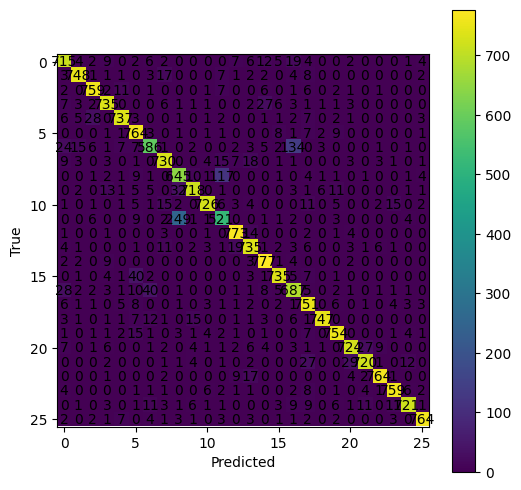

In [49]:
cm = compute_confusion_matrix(model_C,test_loader)

plot_confusion_matrix(cm)

In [50]:
def show_misclassified(model,loader,n=10):

    model.eval()

    wrong=[]

    letters = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"

    with torch.no_grad():

        for X,y in loader:

            out = model(X.to(device).view(X.size(0),-1))

            preds = out.argmax(dim=1).cpu()

            y = y - 1

            for i in range(len(y)):

                if preds[i] != y[i]:

                    wrong.append((X[i].squeeze(),preds[i].item(),y[i].item()))

                if len(wrong) >= n:
                    break

            if len(wrong) >= n:
                break

    plt.figure(figsize=(12,3))

    for i,(img,pred,true) in enumerate(wrong):

        plt.subplot(1,n,i+1)

        plt.imshow(img,cmap="gray")

        plt.title(f"P:{letters[pred]} T:{letters[true]}")

        plt.axis("off")

    plt.show()

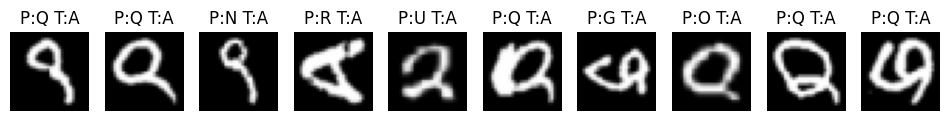

In [51]:
show_misclassified(model_C,test_loader,10)

In [52]:
print("Model Comparison\n")

print("Model A | Params:",paramsA,"| Accuracy:",accA,"| Time:",timeA)
print("Model B | Params:",paramsB,"| Accuracy:",accB,"| Time:",timeB)
print("Model C | Params:",paramsC,"| Accuracy:",accC,"| Time:",timeC)
print("Small Model | Params:",count_parameters(small_model),"| Accuracy:",accS,"| Time:",timeS)
print("Large Model | Params:",count_parameters(large_model),"| Accuracy:",accL,"| Time:",timeL)
print("BatchNorm Model | Params:",paramsBN,"| Accuracy:",accBN,"| Time:",timeBN)

Model Comparison

Model A | Params: 25978 | Accuracy: 79.42788461538461 | Time: 324.8063774108887
Model B | Params: 110426 | Accuracy: 88.60576923076923 | Time: 357.4773015975952
Model C | Params: 243802 | Accuracy: 90.36057692307692 | Time: 407.28604888916016
Small Model | Params: 3270 | Accuracy: 24.20673076923077 | Time: 320.4572329521179
Large Model | Params: 1765466 | Accuracy: 90.8173076923077 | Time: 1129.2140781879425
BatchNorm Model | Params: 244698 | Accuracy: 91.82692307692308 | Time: 390.64100790023804


Alphabet Recognition Using Neural Networks (EMNIST Dataset)
Introduction ▶

Alphabet recognition is an important task in the field of computer vision and machine learning. It refers to the process of identifying and classifying handwritten or printed letters using computer algorithms. This technology is widely used in applications such as handwriting recognition, document digitization, postal address reading, and automated form processing.

In this project, a neural network-based approach is used to classify handwritten alphabets from images. The model is trained using the EMNIST (Extended MNIST) dataset, which contains handwritten character images. Each image represents a letter from A to Z, and the task of the neural network is to correctly identify which alphabet the image represents.

The implementation is done using Python and the PyTorch deep learning framework. Multiple neural network architectures are trained and compared to analyze their performance, training time, and accuracy. Additionally, techniques such as Batch Normalization are used to improve training stability and performance.

The goal of this project is to understand how neural networks learn patterns from image data and how different model complexities affect performance.

Dataset Description ▶

The dataset used in this project is EMNIST Letters, which is an extension of the well-known MNIST dataset.

EMNIST contains grayscale images of handwritten characters. Each image has a resolution of 28 × 28 pixels and contains a single alphabet written by a human. The dataset contains 26 classes, representing the alphabets A to Z.

The dataset is divided into two parts:

Training Dataset – used to train the neural network model.

Test Dataset – used to evaluate the performance of the trained model.

Each image is converted into a tensor and normalized using the transformation:

Convert image to tensor

Normalize pixel values between -1 and 1

The normalization process helps improve training stability and convergence.

To load and manage the dataset efficiently, PyTorch DataLoader is used. It loads data in batches and allows shuffling during training to prevent the model from memorizing the order of samples.

Data Visualization ▶

Before training the model, some sample images from the dataset are visualized. This step helps verify that the dataset is loaded correctly and allows us to observe the structure of the images.

Each image is displayed using the Matplotlib library. The grayscale images represent handwritten alphabets. By visualizing multiple samples, we can see variations in handwriting style, thickness, and shape.

This variation makes the classification task more challenging and realistic because the model must learn the underlying patterns of each alphabet instead of memorizing exact shapes.

Neural Network Architecture ▶

The model used in this project is a Multi-Layer Perceptron (MLP) neural network.

Since each image is 28 × 28 pixels, it contains 784 input features when flattened. Therefore, the input layer of the neural network contains 784 neurons.

Several models with different architectures are tested:

Model A :-

Structure:

784 → 32 → 26

This model contains one hidden layer with 32 neurons. It is a relatively simple model with fewer parameters.

Model B :-

Structure:

784 → 128 → 64 → 26

This model contains two hidden layers, which allows the network to learn more complex patterns.

Model C :-

Structure:

784 → 256 → 128 → 64 → 26

This model is deeper and contains more neurons, enabling it to learn more detailed representations of the input images.

The activation function used between layers is ReLU (Rectified Linear Unit), which helps introduce non-linearity into the model.

The final layer outputs 26 neurons, corresponding to the 26 alphabet classes.

Training Process ▶

The models are trained using the Adam optimizer, which is an adaptive learning rate optimization algorithm widely used in deep learning.

The loss function used is Cross-Entropy Loss, which is suitable for multi-class classification problems.

The training process follows these steps:

Load a batch of images from the training dataset.

Flatten the images into a 784-dimensional vector.

Pass the data through the neural network.

Compute the loss between predicted labels and actual labels.

Perform backpropagation to compute gradients.

Update the model parameters using the optimizer.

This process is repeated for multiple epochs. An epoch represents one complete pass through the training dataset.

During training, the following metrics are recorded:

Training loss

Validation loss

Model accuracy

Tracking these metrics helps evaluate whether the model is learning effectively.

Underfitting and Overfitting Analysis ▶

To better understand neural network behavior, two additional models are trained.

Underfitting Model

A very small model with structure:

784 → 4 → 26

This model has very limited capacity and cannot learn complex patterns from the data. As a result, it produces higher loss and lower accuracy.

This phenomenon is called underfitting, where the model is too simple to represent the underlying data distribution.

Overfitting Model ▶

A very large neural network is also trained:

784 → 1024 → 512 → 512 → 256 → 128 → 64 → 26

This model contains a large number of parameters. It can memorize the training data very well but may not generalize effectively to unseen data.

This phenomenon is called overfitting, where the model performs very well on training data but poorly on new data.

Comparing underfitting and overfitting models helps understand the importance of choosing the right model complexity.

Batch Normalization ▶

To improve training stability and convergence, Batch Normalization is introduced in one of the models.

Batch Normalization normalizes the activations of each layer during training. This has several advantages:

Faster training

Reduced internal covariate shift

Improved model generalization

Higher stability during training

The Batch Normalization model contains layers structured as:

Linear Layer → BatchNorm → ReLU

This structure helps the model learn more efficiently and achieve better performance.

Confusion Matrix Analysis ▶

To evaluate classification performance, a confusion matrix is generated.

A confusion matrix is a table that compares:

Actual labels (True values)

Predicted labels

Each row represents the true class, while each column represents the predicted class.

The matrix helps identify which alphabets are frequently misclassified. For example, letters that look similar in handwriting such as:

O and Q

I and L

C and G

may sometimes be confused by the model.

Analyzing the confusion matrix provides deeper insight into model performance.

Misclassified Image Visualization ▶

Another useful evaluation technique is displaying misclassified images.

The model predictions are compared with the true labels, and incorrectly classified images are collected. These images are then displayed along with:

Predicted label

True label

This visualization helps understand why the model makes certain mistakes and whether the errors are due to ambiguous handwriting or model limitations.

Model Comparison ▶

Finally, all trained models are compared based on the following metrics:

Number of parameters

Accuracy

Training time

This comparison helps determine which model provides the best balance between complexity and performance.

Typically, medium-sized models tend to perform best because they are powerful enough to learn complex patterns but not so large that they overfit the data.

Conclusion ▶

This project demonstrates how neural networks can be used for handwritten alphabet recognition. Using the EMNIST dataset and the PyTorch framework, multiple neural network architectures were implemented and evaluated.

The experiments showed that model complexity plays an important role in performance. Small models tend to underfit, while extremely large models may overfit the data. Techniques such as Batch Normalization help improve training stability and accuracy.

Additionally, evaluation tools such as confusion matrices and misclassified image visualization provide valuable insights into model behavior.

Overall, this project provides a practical understanding of neural network training, model comparison, and image classification using deep learning techniques.